# Cell 1 — Import libraries


In [1]:
import os
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import geopandas as gpd

try:
    import geobr
    HAS_GEOBR = True
except Exception:
    HAS_GEOBR = False

from sklearn.preprocessing import MinMaxScaler


# Cell 2 — Configuration & paths


In [2]:
# ── Paths ────────────────────────────────────────────────────────────────────
# Nếu notebook nằm trong notebooks/, PROJECT_ROOT phải là thư mục cha
PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

PROCESSED_OLIST = PROJECT_ROOT / "data" / "processed" / "olist"
RAW_OLIST       = PROJECT_ROOT / "data" / "raw" / "olist"
RAW_POP         = PROJECT_ROOT / "data" / "external" / "br_ibge_populacao_uf.csv"
RAW_GDP         = PROJECT_ROOT / "data" / "external" / "br_ibge_pib_uf.csv"
RAW_GEOBR       = PROJECT_ROOT / "data" / "external" / "geobr_shapefiles"

PRED_PATH        = PROCESSED_OLIST / "predicted_next_week_revenue.csv"
OUTPUT_FEATURES  = PROCESSED_OLIST / "state_week_eps_features.csv"
OUTPUT_RANKING   = PROCESSED_OLIST / "eps_state_ranking.csv"

FIG_DIR = PROJECT_ROOT / "reports" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

# ── EPS weights ───────────────────────────────────────────────────────────────
CONFIG = {
    "rolling_window":            4,
    "use_log_predicted_revenue": True,
    "use_delivered_orders_only": True,
    "growth_clip_lower":         0.01,
    "growth_clip_upper":         0.99,
    "weights": {
        "PD": 0.35,
        "GP": 0.20,
        "MS": 0.20,
        "PG": 0.15,
        "SI": 0.05,
        "LC": 0.05,
    },
    "logistics_mode": "freight_delivery_average",
}

# ── Validate required files exist ─────────────────────────────────────────────
for p in [PRED_PATH, RAW_POP, RAW_GDP]:
    assert p.exists(), f"[ERROR] Missing required file: {p}"


# Cell 3 — Helper functions


In [3]:
VALID_STATES = [
    "AC","AL","AP","AM","BA","CE","DF","ES","GO",
    "MA","MT","MS","MG","PA","PB","PR","PE","PI",
    "RJ","RN","RS","RO","RR","SC","SP","SE","TO"
]

def minmax_series(s: pd.Series) -> pd.Series:
    """Min-max normalize. Trả về zeros nếu tất cả giá trị bằng nhau."""
    s = pd.Series(s).astype(float)
    mn, mx = s.min(), s.max()
    if np.isclose(mn, mx):
        return pd.Series(np.zeros(len(s)), index=s.index)
    return (s - mn) / (mx - mn)

def clip_series(s: pd.Series, lower: float = 0.01, upper: float = 0.99) -> pd.Series:
    """Clip theo quantile để loại outlier."""
    s = pd.Series(s).astype(float)
    return s.clip(s.quantile(lower), s.quantile(upper))

def parse_week_range(s: str):
    """Parse '2018-08-27/2018-09-02' → (Timestamp, Timestamp)."""
    start, end = str(s).split("/")
    return pd.to_datetime(start), pd.to_datetime(end)

def attach_nearest_past_year(
    panel: pd.DataFrame,
    external: pd.DataFrame,
    value_cols: list,
    state_col: str = "state",
) -> pd.DataFrame:
    """
    Join external (population/GDP) vào panel theo năm gần nhất trong quá khứ.
    Phù hợp dataset nhỏ (<= 5000 rows). Với dataset lớn hơn, dùng merge_asof.
    """
    external = external.sort_values([state_col, "year"])
    rows = []
    for _, row in panel[["customer_state", "year"]].drop_duplicates().iterrows():
        st, yr = row["customer_state"], int(row["year"])
        sub = external[(external[state_col] == st) & (external["year"] <= yr)]
        if sub.empty:
            sub = external[external[state_col] == st]
        record = {"customer_state": st, "year": yr}
        if sub.empty:
            for c in value_cols:
                record[c] = np.nan
        else:
            latest = sub.sort_values("year").iloc[-1]
            for c in value_cols:
                record[c] = latest[c]
        rows.append(record)
    return panel.merge(pd.DataFrame(rows), on=["customer_state", "year"], how="left")


# Cell 4 — Load input data


In [4]:
# ── Load prediction ───────────────────────────────────────────────────────────
pred = pd.read_csv(PRED_PATH)

required_pred_cols = ["customer_state", "year_week_current", "predicted_next_week_revenue"]
missing_cols = set(required_pred_cols) - set(pred.columns)
assert not missing_cols, f"[ERROR] Prediction file missing columns: {missing_cols}"
assert pred["customer_state"].nunique() <= 27
assert pred["predicted_next_week_revenue"].notna().all()

# ── Load Olist tables ─────────────────────────────────────────────────────────
def load_table(filename: str, required_cols: list) -> pd.DataFrame:
    """Load từ processed trước, fallback sang raw nếu thiếu column."""
    processed_path = PROCESSED_OLIST / filename
    raw_path       = RAW_OLIST / f"olist_{filename.replace('.csv','')}_dataset.csv"

    for path in [processed_path, raw_path]:
        if path.exists():
            df = pd.read_csv(path)
            if all(c in df.columns for c in required_cols):
                print(f"[OK] Loaded {path.name} from {path.parent.name}")
                return df

    raise FileNotFoundError(
        f"[ERROR] Cannot find '{filename}' with required columns {required_cols} "
        f"in processed or raw directory."
    )

customers = load_table("customers.csv", ["customer_id", "customer_unique_id", "customer_state"])
orders    = load_table("orders.csv",    ["order_id", "customer_id", "order_status", "order_purchase_timestamp"])
items     = load_table("order_items.csv", ["order_id", "seller_id", "price", "freight_value"])
sellers   = load_table("sellers.csv",   ["seller_id", "seller_state"])

# ── Load population & GDP ─────────────────────────────────────────────────────
population = pd.read_csv(RAW_POP)
gdp_df     = pd.read_csv(RAW_GDP)

print(f"\nPopulation columns: {population.columns.tolist()}")
print(f"GDP columns:        {gdp_df.columns.tolist()}")


[OK] Loaded customers.csv from olist
[OK] Loaded orders.csv from olist
[OK] Loaded order_items.csv from olist
[OK] Loaded sellers.csv from olist

Population columns: ['year', 'state', 'population']
GDP columns:        ['year', 'state_id', 'state', 'gdp', 'net_taxes', 'gross_value_added', 'agriculture_gva', 'industry_gva', 'services_gva', 'public_admin_gva']


# Cell 5 — Clean & prepare base tables


In [5]:
# ── Orders: parse timestamps, compute delivery time ──────────────────────────
orders["order_purchase_timestamp"] = pd.to_datetime(
    orders["order_purchase_timestamp"], errors="coerce"
)

if "order_delivered_customer_date" in orders.columns:
    orders["order_delivered_customer_date"] = pd.to_datetime(
        orders["order_delivered_customer_date"], errors="coerce"
)
    orders["delivery_time_days"] = (
        orders["order_delivered_customer_date"] - orders["order_purchase_timestamp"]
    ).dt.total_seconds() / 86400
else:
    orders["delivery_time_days"] = np.nan

# Chỉ giữ delivered orders
if "order_status" in orders.columns:
    orders = orders[orders["order_status"] == "delivered"].copy()

# ── Items: tính revenue nếu chưa có ──────────────────────────────────────────
if "revenue" not in items.columns:
    items["revenue"] = items["price"] + items["freight_value"]

# ── Population ────────────────────────────────────────────────────────────────
population["state"] = population["state"].astype(str).str.strip().str.upper()
population = population[population["state"].isin(VALID_STATES)].copy()
population = population.dropna(subset=["year", "state", "population"])
population["year"]       = population["year"].astype(int)
population["population"] = pd.to_numeric(population["population"], errors="coerce")
population = population[population["population"] > 0]

# ── GDP ───────────────────────────────────────────────────────────────────────
gdp_df["state"] = gdp_df["state"].astype(str).str.strip().str.upper()
gdp_df = gdp_df[gdp_df["state"].isin(VALID_STATES)].copy()
gdp_df = gdp_df.dropna(subset=["year", "state", "gdp"])
gdp_df["year"] = gdp_df["year"].astype(int)
gdp_df["gdp"]  = pd.to_numeric(gdp_df["gdp"], errors="coerce")
gdp_df = gdp_df[gdp_df["gdp"] > 0]


# Cell 6 — Build transaction fact table


In [6]:
fact = (
    orders
    .merge(
        customers[["customer_id", "customer_unique_id", "customer_state"]],
        on="customer_id", how="left"
    )
    .merge(
        items[["order_id", "seller_id", "product_id", "price", "freight_value", "revenue"]],
        on="order_id", how="left"
    )
)

fact = fact[fact["customer_state"].isin(VALID_STATES)].copy()
fact = fact.dropna(subset=["order_purchase_timestamp", "customer_state"])

# Tạo week period (Mon–Sun)
fact["week_period"] = fact["order_purchase_timestamp"].dt.to_period("W-SUN")
fact["week_start"]  = fact["week_period"].apply(lambda p: p.start_time)
fact["week_end"]    = fact["week_period"].apply(lambda p: p.end_time.normalize())
fact["year"]        = fact["week_start"].dt.year

print(f"Fact table: {fact.shape[0]:,} rows | "
      f"{fact['customer_state'].nunique()} states | "
      f"{fact['week_start'].nunique()} weeks")


Fact table: 110,188 rows | 27 states | 91 weeks


# Cell 7 — Aggregate state-week features


In [7]:
state_week = (
    fact.groupby(["customer_state", "week_start", "week_end", "year"])
    .agg(
        revenue          = ("revenue",            "sum"),
        order_count      = ("order_id",           "nunique"),
        unique_customers = ("customer_unique_id", "nunique"),
        seller_count     = ("seller_id",          "nunique"),
        avg_price        = ("price",              "mean"),
        avg_freight_value= ("freight_value",      "mean"),
        avg_delivery_time= ("delivery_time_days", "mean"),
    )
    .reset_index()
)

# Tạo full panel để không mất tuần có 0 giao dịch
all_weeks  = pd.date_range(state_week["week_start"].min(),
                           state_week["week_start"].max(), freq="W-MON")
panel_idx  = pd.MultiIndex.from_product(
    [VALID_STATES, all_weeks], names=["customer_state", "week_start"]
)
state_week = (
    state_week.set_index(["customer_state", "week_start"])
    .reindex(panel_idx)
    .reset_index()
)
state_week["week_end"] = state_week["week_start"] + pd.Timedelta(days=6)
state_week["year"]     = state_week["week_start"].dt.year

# Fill zeros / forward-fill
for col in ["revenue", "order_count", "unique_customers", "seller_count"]:
    state_week[col] = state_week[col].fillna(0)

for col in ["avg_price", "avg_freight_value", "avg_delivery_time"]:
    state_week[col] = (
        state_week.groupby("customer_state")[col]
        .transform(lambda s: s.ffill().bfill())
    )
    state_week[col] = state_week[col].fillna(state_week[col].median())

print(f"State-week panel: {state_week.shape}")


State-week panel: (2781, 11)


# Cell 8 — Join population & GDP


In [8]:
state_week = attach_nearest_past_year(
    state_week, population, value_cols=["population"]
)
state_week = attach_nearest_past_year(
    state_week, gdp_df, value_cols=["gdp"]
)
state_week["gdp_per_capita"] = state_week["gdp"] / state_week["population"]

# Validation
assert state_week["population"].notna().mean() > 0.95, "[WARN] >5% rows missing population"
assert state_week["gdp"].notna().mean()        > 0.95, "[WARN] >5% rows missing GDP"


# Cell 9 — Compute rolling historical features


In [9]:
state_week = state_week.sort_values(["customer_state", "week_start"]).copy()
grp = state_week.groupby("customer_state")

W = CONFIG["rolling_window"]  # default = 4

# Lag revenues
for lag in [1, 2, 4, 8]:
    state_week[f"lag_revenue_{lag}w"] = grp["revenue"].shift(lag)

# Rolling revenue (dùng shift(1) để tránh data leakage)
state_week["rolling_revenue_4w"] = grp["revenue"].transform(
    lambda s: s.shift(1).rolling(W, min_periods=1).mean()
)
state_week["rolling_revenue_prev_4w"] = grp["revenue"].transform(
    lambda s: s.shift(W + 1).rolling(W, min_periods=1).mean()
)
state_week["growth_potential_raw"] = (
    (state_week["rolling_revenue_4w"] - state_week["rolling_revenue_prev_4w"])
    / (state_week["rolling_revenue_prev_4w"].abs() + 1e-6)
)

# Rolling customers & sellers
state_week["rolling_customers_4w"] = grp["unique_customers"].transform(
    lambda s: s.shift(1).rolling(W, min_periods=1).sum()
)
state_week["rolling_sellers_4w"] = grp["seller_count"].transform(
    lambda s: s.shift(1).rolling(W, min_periods=1).mean()
)

# Rolling logistics
state_week["avg_freight_4w"] = grp["avg_freight_value"].transform(
    lambda s: s.shift(1).rolling(W, min_periods=1).mean()
)
state_week["avg_delivery_time_4w"] = grp["avg_delivery_time"].transform(
    lambda s: s.shift(1).rolling(W, min_periods=1).mean()
)


# Cell 10 — Merge prediction với state-week features


In [10]:
pred[["current_week_start", "current_week_end"]] = pred["year_week_current"].apply(
    lambda x: pd.Series(parse_week_range(x))
)

eps_base = pred.merge(
    state_week,
    left_on  = ["customer_state", "current_week_start"],
    right_on = ["customer_state", "week_start"],
    how="left"
)

# Debug nếu merge không khớp
if eps_base["revenue"].isna().all():
    print("[DEBUG] Merge thất bại — kiểm tra định dạng tuần:")
    print("pred week_start sample :", pred["current_week_start"].head(3).tolist())
    print("state_week week_start sample:", state_week["week_start"].tail(3).tolist())
    # Thử align lại tuần
    pred["current_week_start"] = (
        pred["current_week_start"]
        .dt.to_period("W-MON")
        .apply(lambda p: p.start_time)
    )
    eps_base = pred.merge(
        state_week,
        left_on  = ["customer_state", "current_week_start"],
        right_on = ["customer_state", "week_start"],
        how="left"
    )

# Join population & GDP vào eps_base nếu chưa có
if "population" not in eps_base.columns:
    eps_base = attach_nearest_past_year(eps_base, population, ["population"])
if "gdp" not in eps_base.columns:
    eps_base = attach_nearest_past_year(eps_base, gdp_df, ["gdp"])

# Validation
assert eps_base.shape[0] == pred.shape[0], "[ERROR] Row count mismatch after merge"
assert eps_base["population"].notna().all(), "[ERROR] Missing population in some states"
assert eps_base["gdp"].notna().all(),        "[ERROR] Missing GDP in some states"


# Cell 11 — Compute EPS components


In [11]:
eps = eps_base.copy()

# PD
eps["PD_raw"] = np.log1p(eps["predicted_next_week_revenue"])

# GP
eps["GP_raw"] = clip_series(
    eps["growth_potential_raw"],
    lower=CONFIG["growth_clip_lower"],
    upper=CONFIG["growth_clip_upper"],
)

# MS
national_avg_gdppc = eps["gdp"].sum() / eps["population"].sum()
eps["gdp_per_capita_index"] = eps["gdp_per_capita"] / national_avg_gdppc
eps["MS_raw"] = np.log1p(eps["population"]) * eps["gdp_per_capita_index"]

# PG
eps["MS_norm_temp"]          = minmax_series(eps["MS_raw"])
eps["penetration_norm_temp"] = minmax_series(
    eps["rolling_customers_4w"] / eps["population"]
)
eps["PG_raw"] = eps["MS_norm_temp"] - eps["penetration_norm_temp"]

# SI
eps["SI_raw"] = eps["rolling_sellers_4w"] / eps["population"] * 100_000

# LC
if CONFIG["logistics_mode"] == "freight_delivery_average":
    eps["LC_raw"] = (
        0.5 * minmax_series(eps["avg_freight_4w"])
        + 0.5 * minmax_series(eps["avg_delivery_time_4w"])
    )
else:
    eps["LC_raw"] = minmax_series(eps["avg_freight_4w"])

# Normalize tất cả thành phần về [0, 1]
for raw_col in ["PD_raw", "GP_raw", "MS_raw", "PG_raw", "SI_raw", "LC_raw"]:
    norm_col = raw_col.replace("_raw", "_norm")
    eps[norm_col] = minmax_series(eps[raw_col])

# Tính EPS tổng hợp
W = CONFIG["weights"]
eps["EPS"] = (
     W["PD"] * eps["PD_norm"]
  +  W["GP"] * eps["GP_norm"]
  +  W["MS"] * eps["MS_norm"]
  +  W["PG"] * eps["PG_norm"]
  -  W["SI"] * eps["SI_norm"]
  -  W["LC"] * eps["LC_norm"]
)

eps["EPS_0_100"] = 100 * (
    (eps["EPS"] - eps["EPS"].min())
    / (eps["EPS"].max() - eps["EPS"].min() + 1e-9)
)
eps["rank_eps"] = eps["EPS_0_100"].rank(ascending=False, method="dense").astype(int)


# Cell 12 — Interpretation column


In [12]:
def interpret_eps(row) -> str:
    reasons = []
    if row["PD_norm"] >= 0.75: reasons.append("high predicted demand")
    if row["GP_norm"] >= 0.75: reasons.append("strong growth")
    if row["MS_norm"] >= 0.75: reasons.append("large market size")
    if row["PG_norm"] >= 0.75: reasons.append("high penetration gap")
    if row["SI_norm"] >= 0.75: reasons.append("high seller competition")
    if row["LC_norm"] >= 0.75: reasons.append("high logistics cost")
    return ", ".join(reasons) if reasons else "balanced profile"

eps["interpretation"] = eps.apply(interpret_eps, axis=1)


# Cell 13 — Save outputs


In [13]:
RANKING_COLS = [
    "customer_state", "year_week_current", "predicted_next_week_revenue",
    "PD_norm", "GP_norm", "MS_norm", "PG_norm", "SI_norm", "LC_norm",
    "EPS", "EPS_0_100", "rank_eps", "interpretation",
]

eps_ranking = eps[RANKING_COLS].sort_values("rank_eps").reset_index(drop=True)

eps.to_csv(OUTPUT_FEATURES, index=False)
eps_ranking.to_csv(OUTPUT_RANKING, index=False)

print(f"[SAVED] {OUTPUT_FEATURES}")
print(f"[SAVED] {OUTPUT_RANKING}")
eps_ranking.head(10)


[SAVED] D:\FPT_Syllabus\DAP301m\DAP391m_AI2013_G7\data\processed\olist\state_week_eps_features.csv
[SAVED] D:\FPT_Syllabus\DAP301m\DAP391m_AI2013_G7\data\processed\olist\eps_state_ranking.csv


,customer_state,year_week_current,predicted_next_week_revenue,PD_norm,GP_norm,MS_norm,PG_norm,SI_norm,LC_norm,EPS,EPS_0_100,rank_eps,interpretation
0,SP,2018-08-27/2018-09-02,29519.200406,1.000000,1.000000,0.601780,0.000000,0.766330,0.000000,0.632039,100.000000,1,"high predicted demand, strong growth, high sel..."
1,DF,2018-08-27/2018-09-02,7.767044,0.012207,0.705094,1.000000,1.000000,1.000000,0.206086,0.434987,64.387658,2,"large market size, high penetration gap, high ..."
2,MT,2018-08-27/2018-09-02,12.087307,0.060934,0.778047,0.360515,0.850825,0.284212,0.324126,0.346246,48.349979,3,"strong growth, high penetration gap"
3,PR,2018-08-27/2018-09-02,29.300180,0.163037,0.790905,0.387788,0.558163,0.531262,0.166470,0.341639,47.517397,4,strong growth
4,RS,2018-08-27/2018-09-02,11.979579,0.059928,0.840944,0.412164,0.639986,0.486353,0.260308,0.330261,45.461158,5,strong growth
5,MS,2018-08-27/2018-09-02,12.021243,0.060318,0.771890,0.337902,0.788410,0.297866,0.463187,0.323279,44.199178,6,"strong growth, high penetration gap"
6,RJ,2018-08-27/2018-09-02,20.531368,0.121485,0.820175,0.488862,0.389373,0.707367,0.173554,0.318687,43.369417,7,strong growth
7,SC,2018-08-27/2018-09-02,7.918533,0.014290,0.797032,0.420846,0.610287,0.533289,0.224646,0.302223,40.394011,8,strong growth
8,SE,2018-08-27/2018-09-02,34.777496,0.183246,0.843985,0.047263,0.434280,0.210308,0.689717,0.262527,33.219789,9,strong growth
9,MG,2018-08-27/2018-09-02,15.666120,0.090334,0.873962,0.258069,0.251296,0.577850,0.158592,0.258895,32.563547,10,strong growth


# Cell 14 — Bar chart


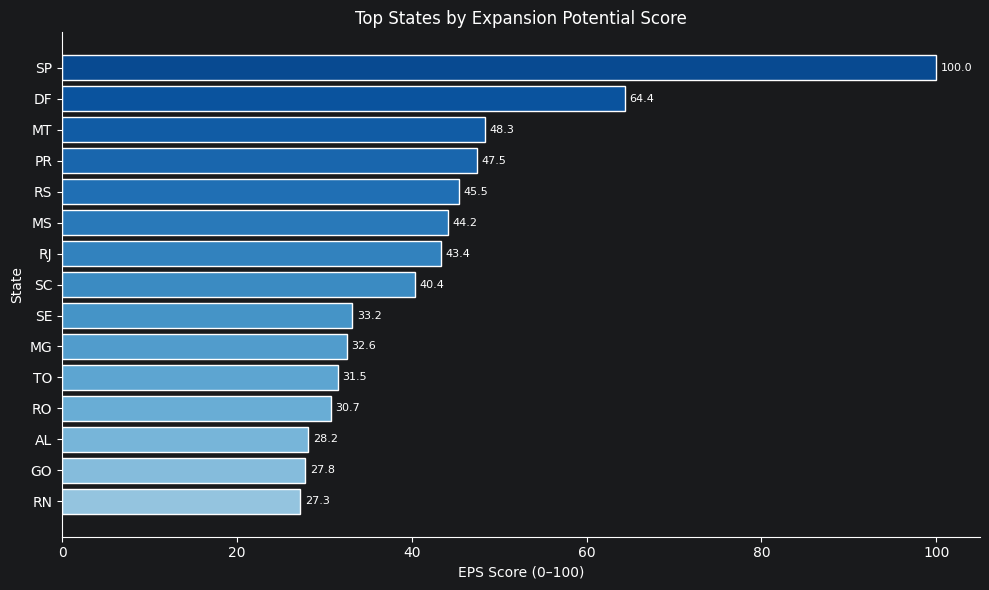

[SAVED] eps_state_ranking_bar.png


In [14]:
top = eps_ranking.sort_values("EPS_0_100", ascending=False).head(15)

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(
    top["customer_state"][::-1],
    top["EPS_0_100"][::-1],
    color=plt.cm.Blues(np.linspace(0.4, 0.9, len(top))),
    edgecolor="white",
)
ax.set_xlabel("EPS Score (0–100)")
ax.set_ylabel("State")
ax.set_title("Top States by Expansion Potential Score")
ax.spines[["top", "right"]].set_visible(False)
for bar, v in zip(bars, top["EPS_0_100"][::-1]):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height() / 2,
            f"{v:.1f}", va="center", fontsize=8)
plt.tight_layout()
plt.savefig(FIG_DIR / "eps_state_ranking_bar.png", dpi=200, bbox_inches="tight")
plt.show()
print(f"[SAVED] eps_state_ranking_bar.png")


# Cell 15 — Choropleth heatmap


In [15]:
# Load shapefile
local_geojson = PROJECT_ROOT / "data" / "external" / "br_states.geojson"
if local_geojson.exists():
    try:
        states_geo = gpd.read_file(local_geojson)
        print("Successfully loaded shapefile using local GeoJSON.")
    except Exception as e:
        print(f"[WARN] Failed to read local GeoJSON: {e}. Trying geobr...")
        states_geo = None
else:
    states_geo = None

if states_geo is None:
    if HAS_GEOBR:
        try:
            states_geo = geobr.read_state(year=2018)
            print("Successfully loaded shapefile using geobr.")
        except Exception as e:
            print(f"[WARN] Failed to read state using geobr: {e}. Trying local shapefile fallback...")
            shp_files = list(RAW_GEOBR.rglob("*.shp"))
            assert shp_files, "[ERROR] No local shapefile found."
            states_shp = [s for s in shp_files if "states" in s.name]
            states_geo = gpd.read_file(states_shp[0] if states_shp else shp_files[0])
    else:
        shp_files = list(RAW_GEOBR.rglob("*.shp"))
        assert shp_files, "[ERROR] No local shapefile found and geobr is not installed."
        states_shp = [s for s in shp_files if "states" in s.name]
        states_geo = gpd.read_file(states_shp[0] if states_shp else shp_files[0])

print("Geo columns:", states_geo.columns.tolist())


Successfully loaded shapefile using local GeoJSON.
Geo columns: ['code_state', 'abbrev_state', 'name_state', 'code_region', 'name_region', 'geometry']


# Cell 16 — Final validation


In [16]:
print("=" * 50)
print("VALIDATION REPORT")
print("=" * 50)

assert eps_ranking["customer_state"].nunique() == pred["customer_state"].nunique(), \
    "[FAIL] State count mismatch"
assert eps_ranking["EPS_0_100"].between(0, 100).all(), \
    "[FAIL] EPS_0_100 out of range"
assert not eps_ranking["customer_state"].duplicated().any(), \
    "[FAIL] Duplicated states in ranking"
for col in ["PD_norm", "GP_norm", "MS_norm", "PG_norm", "SI_norm", "LC_norm"]:
    assert eps_ranking[col].notna().all(), f"[FAIL] Missing values in {col}"

print(f"[PASS] States ranked:    {eps_ranking['customer_state'].nunique()}")
print(f"[PASS] EPS range:        {eps_ranking['EPS_0_100'].min():.2f} – {eps_ranking['EPS_0_100'].max():.2f}")
print(f"[PASS] No duplicates")
print(f"[PASS] All components non-null")
print()
print("Top 10 States by EPS:")
display(eps_ranking.head(10))


VALIDATION REPORT
[PASS] States ranked:    27
[PASS] EPS range:        0.00 – 100.00
[PASS] No duplicates
[PASS] All components non-null

Top 10 States by EPS:


,customer_state,year_week_current,predicted_next_week_revenue,PD_norm,GP_norm,MS_norm,PG_norm,SI_norm,LC_norm,EPS,EPS_0_100,rank_eps,interpretation
0,SP,2018-08-27/2018-09-02,29519.200406,1.000000,1.000000,0.601780,0.000000,0.766330,0.000000,0.632039,100.000000,1,"high predicted demand, strong growth, high sel..."
1,DF,2018-08-27/2018-09-02,7.767044,0.012207,0.705094,1.000000,1.000000,1.000000,0.206086,0.434987,64.387658,2,"large market size, high penetration gap, high ..."
2,MT,2018-08-27/2018-09-02,12.087307,0.060934,0.778047,0.360515,0.850825,0.284212,0.324126,0.346246,48.349979,3,"strong growth, high penetration gap"
3,PR,2018-08-27/2018-09-02,29.300180,0.163037,0.790905,0.387788,0.558163,0.531262,0.166470,0.341639,47.517397,4,strong growth
4,RS,2018-08-27/2018-09-02,11.979579,0.059928,0.840944,0.412164,0.639986,0.486353,0.260308,0.330261,45.461158,5,strong growth
5,MS,2018-08-27/2018-09-02,12.021243,0.060318,0.771890,0.337902,0.788410,0.297866,0.463187,0.323279,44.199178,6,"strong growth, high penetration gap"
6,RJ,2018-08-27/2018-09-02,20.531368,0.121485,0.820175,0.488862,0.389373,0.707367,0.173554,0.318687,43.369417,7,strong growth
7,SC,2018-08-27/2018-09-02,7.918533,0.014290,0.797032,0.420846,0.610287,0.533289,0.224646,0.302223,40.394011,8,strong growth
8,SE,2018-08-27/2018-09-02,34.777496,0.183246,0.843985,0.047263,0.434280,0.210308,0.689717,0.262527,33.219789,9,strong growth
9,MG,2018-08-27/2018-09-02,15.666120,0.090334,0.873962,0.258069,0.251296,0.577850,0.158592,0.258895,32.563547,10,strong growth


# Mô-đun hóa chuyên nghiệp (Production Ready)

Toàn bộ logic tính toán chỉ số Tiềm năng Mở rộng (EPS), vẽ biểu đồ và xuất báo cáo trong notebook này đã được cấu trúc lại và tối ưu hóa thành một module Python chuyên nghiệp tại [expansion_scoring.py](../src/analysis/expansion_scoring.py).

Bạn có thể chạy trực tiếp module này từ dòng lệnh:
```bash
python src/analysis/expansion_scoring.py
```
Hoặc import vào các file/notebook khác để tái sử dụng:
```python
from src.analysis.expansion_scoring import run_scoring_pipeline
df = run_scoring_pipeline()
```
